In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',  # Export text as text not curves
    'font.size': 16, 
    "lines.linewidth": 2, 
    "axes.labelsize": 18,
    "axes.titlesize": 22
})

In [ ]:
def construct_df():
    dbs = [
        "mcl1_mmgbsa_medoid_chemberta-mtr_shuffled", "mcl1_mmgbsa_medoid_molformer_shuffled"#, "mcl1_mmgbsa_medoid_fingerprint"
    ]
    MOLS_PER_ITER = 600
    dfs = []
    for db in dbs:
        df, top_k, source = load_data(f"results/{db}.sqlite", k_ratio=0.01)
        K = len(top_k)
        dfs.append(df)

    full_df = pd.concat(dfs, ignore_index=True)
    return full_df, K

In [3]:
df, size_top_k = construct_df()

In [4]:
df

,id,experiment_id,molecule,affinity,prediction_mean,prediction_std,acquisition_score,Iteration,cluster,output_file_path,...,output_file,n_clusters,simulator,bandit_confidence,job_id,Embedding Model,Surrogate,Scoring,is_top_k,is_top_k_cum
0,1,1,CCc1cc(OC(=O)C[C@H](C)c2c[nH]c3ccccc23)ccc1Cl,-32.368728,inf,0.000000,1.055114,0,0,None,...,mcl1_mmgbsa_medoid_chemberta-mtr_other,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0
1,2,1,COC(=O)c1[nH]c2ccccc2c1SC#N,-24.668707,-32.368728,1.618229,0.645580,1,0,None,...,mcl1_mmgbsa_medoid_chemberta-mtr_other,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0
2,3,1,NC(=O)Cc1ccc(C(=O)COC(=O)c2[nH]c3c(Br)cccc3c2C...,-27.270606,-32.424459,0.106860,0.076166,2,0,None,...,mcl1_mmgbsa_medoid_chemberta-mtr_other,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0
3,4,1,O=C(CCc1c(-c2ccc(F)cc2)[nH]c2c(Cl)cccc12)O[C@@...,-30.984000,-29.214732,2.551384,0.132834,3,0,None,...,mcl1_mmgbsa_medoid_chemberta-mtr_other,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0
4,5,1,O=C(CCc1c(-c2ccc(F)cc2)[nH]c2ccc(F)cc12)O[C@@H...,-35.220181,-30.009712,2.141240,0.146436,4,0,None,...,mcl1_mmgbsa_medoid_chemberta-mtr_other,1,None,1.0,0,ChemBERTa-2,Linear,Expected Improvement,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75616,25203,7,O=C(CCc1c(-c2ccc(F)cc2)[nH]c2ccccc12)Oc1cc(F)c...,-39.246882,-36.580531,5.217480,0.000344,3596,0,None,...,mcl1_mmgbsa_medoid_fingerprint,1,None,1.0,0,Morgan Fingerprint,Linear,Expected Improvement,False,371
75617,25204,7,O=C(CCc1c(-c2ccc(F)cc2)[nH]c2ccccc12)O[C@H]1C[...,-38.411152,-36.642755,5.201662,0.000345,3597,0,None,...,mcl1_mmgbsa_medoid_fingerprint,1,None,1.0,0,Morgan Fingerprint,Linear,Expected Improvement,False,371
75618,25205,7,CCCN(CCC)CCOC(=O)c1[nH]c2c(Br)cccc2c1CCCO,-42.882102,-36.031262,5.364796,0.000344,3598,0,None,...,mcl1_mmgbsa_medoid_fingerprint,1,None,1.0,0,Morgan Fingerprint,Linear,Expected Improvement,False,371
75619,25206,7,CN(C)CC[C@@H](OC(=O)c1[nH]c2c(Br)cccc2c1CCCO)c...,-36.127286,-35.058635,5.645887,0.000363,3599,0,None,...,mcl1_mmgbsa_medoid_fingerprint,1,None,1.0,0,Morgan Fingerprint,Linear,Expected Improvement,False,371


Text(0.5, 0, 'Medoid')

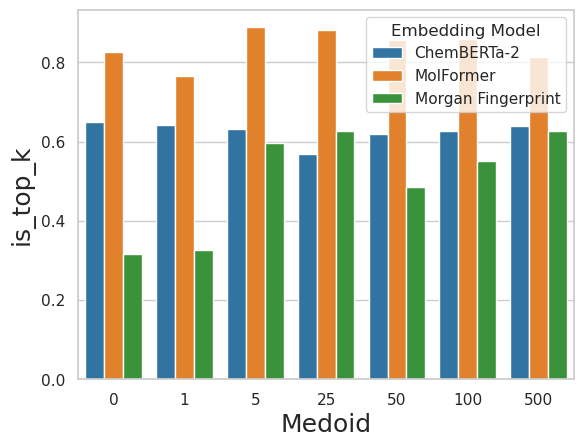

In [5]:
g = sns.barplot(
    df, y="is_top_k", x="init_batch_size", hue="Embedding Model", estimator=lambda x: x.sum() / size_top_k, errorbar=None
)
g.set_xlabel("Medoid")

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

def plot_progress(data):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 6), sharex=True, sharey=True)
    ax1.set_facecolor('white')
    ax2.set_facecolor('white')
    fig.set_facecolor('white')

    for ax, (gvar, d) in zip([ax1, ax2, ax3], data.groupby("Embedding Model")):

        print(gvar)

        ax.set_title(gvar)

        batch_sizes = sorted(d['init_batch_size'].unique())
        n_colors = len(batch_sizes)
        norm = Normalize(vmin=min(batch_sizes), vmax=max(batch_sizes))
        colors = plt.cm.viridis(np.linspace(0, 1, n_colors))

        for color, (bs, group) in zip(colors, d.groupby(["init_batch_size"])):
            bs = bs[0]

            per_run = group.groupby(["experiment_id", "Iteration"])["is_top_k_cum"].max()
            retrieval = per_run.groupby(["Iteration"]).agg(["mean", "sem"]) / size_top_k

            retrieval["mean"].plot(ax=ax, color=color, label=bs)
            ax.fill_between(
                retrieval.index, retrieval["mean"] - retrieval["sem"], retrieval["mean"] + retrieval["sem"], color=color, alpha=0.2
            )
        
        ax.set_xlabel("#Simulations")

    ax1.set_ylabel("Percentage top-1% found")
    leg = ax3.legend(title='Centroid', 
                            loc='center left',
                            bbox_to_anchor=(1.02, 0.5),
                            frameon=True,
                            edgecolor='none',
                            title_fontsize=10)
    leg.get_frame().set_facecolor('white')

    return fig

ChemBERTa-2
MolFormer
Morgan Fingerprint


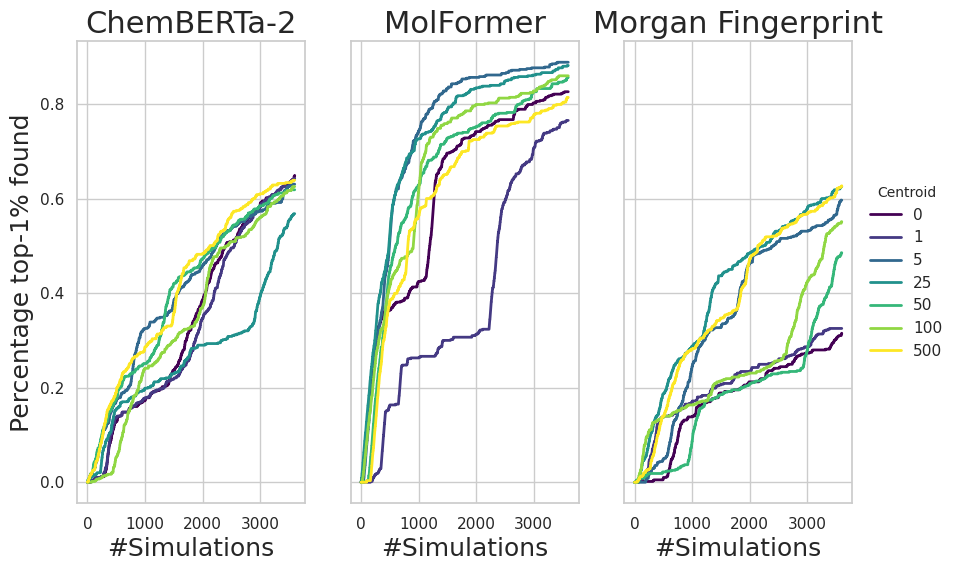

In [13]:
fig = plot_progress(df[df["init_sampler"] == "xth-closest"])
fig.savefig("figures/medoid.pdf")

In [16]:
(df.groupby(["Embedding Model", "init_batch_size"])["is_top_k"].sum() / size_top_k).groupby("Embedding Model").mean()

Embedding Model
ChemBERTa-2           0.624910
MolFormer             0.841966
Morgan Fingerprint    0.503975
Name: is_top_k, dtype: float64